In [ ]:
# !python --version

In [1]:
!pip install uv

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.9/26.9 MB 5.0 MB/s eta 0:00:00


In [2]:
!uv pip install matplotlib pandas

Using Python 3.12.13 environment at: /usr
Checked 2 packages in 71ms


In [3]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


# **1. Perkenalan Dataset**

* Sindrom ovarium polikistik (PCOS) adalah gangguan yang ditandai dengan siklus menstruasi yang jarang, tidak teratur, atau berkepanjangan, serta seringkali disertai kadar hormon laki-laki (androgen) yang berlebihan.

* Kumpulan data ini berisi semua parameter fisik dan klinis untuk mendiagnosis PCOS dan masalah yang berkaitan dengan infertilitas.

* Data dikumpulkan dari 10 rumah sakit berbeda di seluruh Kerala, India.

Sumber dataset bisa diakses [disini](https://www.kaggle.com/datasets/prasoonkottarathil/polycystic-ovary-syndrome-pcos/data)

# **2. Import Library**

In [4]:
import re
import math

# Data Processing
import numpy as np
import pandas as pd

# Data Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# **3. Load Dataset**

In [5]:
def load_dataset(path1, path2=None):
  df1 = pd.read_csv(path1)
  df2 = pd.read_excel(path2, sheet_name="Full_new") if path2 and path2.endswith(".xlsx") else (pd.read_csv(path2) if path2 else None)

  final_df = pd.merge(df2, df1, on="Patient File No.", suffixes=("","_y"), how="left") if df2 is not None else df1

  # Drop unwated & repeated features after merging
  final_df = final_df.loc[:, ~final_df.columns.str.contains(r"_y$|Unnamed")]

  print("✅ Data successfully loaded")

  return final_df

file_path1 = "/content/drive/MyDrive/dataset/PCOS_infertility.csv"
file_path2 = "/content/drive/MyDrive/dataset/PCOS_data_without_infertility.xlsx"

df = load_dataset(file_path1, file_path2)

✅ Data successfully loaded


In [6]:
df.head()

,Sl. No,Patient File No.,PCOS (Y/N),Age (yrs),Weight (Kg),Height(Cm),BMI,Blood Group,Pulse rate(bpm),RR (breaths/min),...,Pimples(Y/N),Fast food (Y/N),Reg.Exercise(Y/N),BP _Systolic (mmHg),BP _Diastolic (mmHg),Follicle No. (L),Follicle No. (R),Avg. F size (L) (mm),Avg. F size (R) (mm),Endometrium (mm)
0,1,1,0,28,44.6,152.0,19.300000,15,78,22,...,0,1.0,0,110,80,3,3,18.0,18.0,8.5
1,2,2,0,36,65.0,161.5,24.921163,15,74,20,...,0,0.0,0,120,70,3,5,15.0,14.0,3.7
2,3,3,1,33,68.8,165.0,25.270891,11,72,18,...,1,1.0,0,120,80,13,15,18.0,20.0,10.0
3,4,4,0,37,65.0,148.0,29.674945,13,72,20,...,0,0.0,0,120,70,2,2,15.0,14.0,7.5
4,5,5,0,25,52.0,161.0,20.060954,11,72,18,...,0,0.0,0,120,80,3,4,16.0,14.0,7.0


# **4. Exploratory Data Analysis (EDA)**

In [7]:
# Constant HEX color code for visualization
COLOR_PALETTE = ["#009662", "#ff6361"]
DARK_COLOR = "#003f5c"
LABEL_COLOR = "#2c2c2c"

In [8]:
total_rows, total_cols = df.shape
print(f"Number of rows: {total_rows}")
print(f"Number of columns: {total_cols}")

Number of rows: 541
Number of columns: 44


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541 entries, 0 to 540
Data columns (total 44 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Sl. No                  541 non-null    int64  
 1   Patient File No.        541 non-null    int64  
 2   PCOS (Y/N)              541 non-null    int64  
 3    Age (yrs)              541 non-null    int64  
 4   Weight (Kg)             541 non-null    float64
 5   Height(Cm)              541 non-null    float64
 6   BMI                     541 non-null    float64
 7   Blood Group             541 non-null    int64  
 8   Pulse rate(bpm)         541 non-null    int64  
 9   RR (breaths/min)        541 non-null    int64  
 10  Hb(g/dl)                541 non-null    float64
 11  Cycle(R/I)              541 non-null    int64  
 12  Cycle length(days)      541 non-null    int64  
 13  Marraige Status (Yrs)   540 non-null    float64
 14  Pregnant(Y/N)           541 non-null    in

If you've noticed, there's a typo in the column name in index 13. Therefore, we'll change the name to the correct spelling.

In [10]:
columns = df.columns.tolist()

columns[13] = "Marriage Status (Yrs)"

In [11]:
old_col_names = columns.copy()
is_contain_whitespace = any(col != col.strip() or bool(re.search(r"\s{2,}", col)) for col in old_col_names)

dirty_col_names = [col for col in old_col_names if col != col.strip() or re.search(r"\s{2,}", col)]

if not is_contain_whitespace:
    print("✅ Column names are clean and ready to go")
else:
    print("❌ Column names are still dirty and need to be adjusted")
    print(f"Dirty column names: {dirty_col_names}")

❌ Column names are still dirty and need to be adjusted
Dirty column names: [' Age (yrs)', 'Height(Cm) ', 'Pulse rate(bpm) ', '  I   beta-HCG(mIU/mL)', 'II    beta-HCG(mIU/mL)']


In [12]:
new_col_names = [
    re.sub(r"([a-zA-Z])\(|\s+", lambda x: f"{x.group(1)} (" if x.group(1) else " ", col).strip()
    for col in old_col_names
]

df.columns = new_col_names

In [13]:
object_cols = df.select_dtypes(include="object").columns

for col in object_cols:
  data_val = df[col].iloc[0]
  data_type = type(data_val)

  print(f"{col} contains data of type {data_type.__name__}")
  print(f"{df[col].head()}\n")

II beta-HCG (mIU/mL) contains data of type float
0      1.99
1      1.99
2    494.08
3      1.99
4    801.45
Name: II beta-HCG (mIU/mL), dtype: object

AMH (ng/mL) contains data of type float
0    2.07
1    1.53
2    6.63
3    1.22
4    2.26
Name: AMH (ng/mL), dtype: object



As you can see, the data in the ```II beta-HCG (mIU/mL)``` and ```AMH (ng/mL)``` columns are displayed as numbers, but surprisingly, their data type is **object**. This indicates that the numeric data is stored as a string and needs to be converted to avoid calculation errors and making it easier for exploratory analysis.

In [14]:
for col in object_cols:
  try:
    df[col] = pd.to_numeric(df[col], errors="raise")
  except ValueError as e:
    print(f"Error converting column '{col}': {e}")

Error converting column 'II beta-HCG (mIU/mL)': Unable to parse string "1.99." at position 123
Error converting column 'AMH (ng/mL)': Unable to parse string "a" at position 305


It turns out that some of the data cannot be converted to a numeric type. Therefore, that data must be handled first before converting again.
* ```II beta-HCG (mIU/mL)``` Simply replace with 1.99 without period at the end.
* ```AMH (ng/mL)``` Replace with the median value of the data distribution.

In [15]:
df.loc[123, "II beta-HCG (mIU/mL)"] = 1.99
df.loc[305, "AMH (ng/mL)"] = df.loc[df.index != 305, "AMH (ng/mL)"].median()

for col in object_cols:
  try:
    df[col] = pd.to_numeric(df[col], errors="raise")
    print(f"✅ {col} converted successfully!")
  except ValueError as e:
    print(f"Error converting column {col}: {e}")

✅ II beta-HCG (mIU/mL) converted successfully!
✅ AMH (ng/mL) converted successfully!


## 4.1 Missing Values Analysis

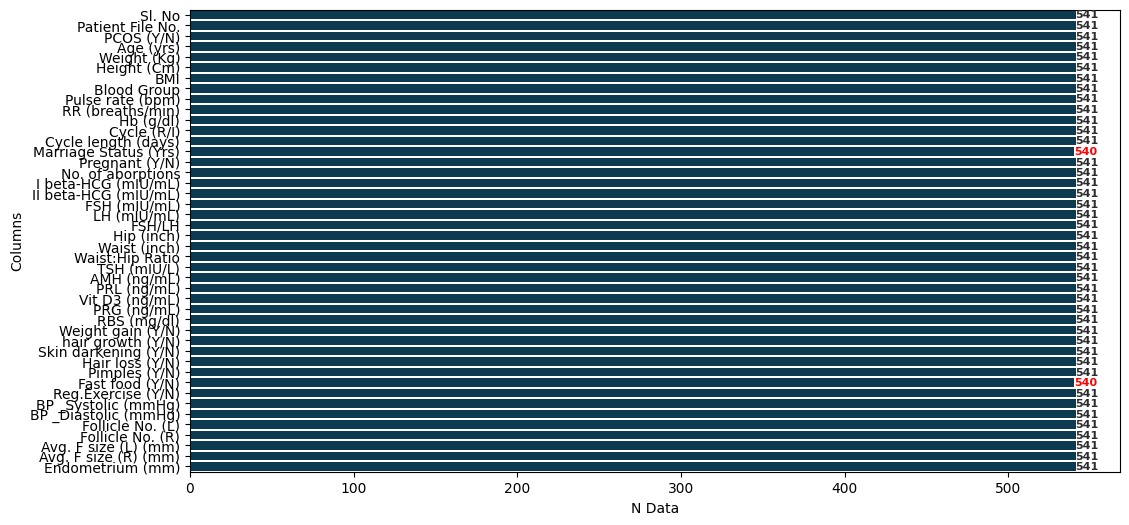

In [16]:
def plot_missing_values(df):
  n_data = df.count()

  plt.figure(figsize=(12, 6))

  ax = sns.barplot(x=n_data.values, y=n_data.index, color=DARK_COLOR)
  labels = ax.bar_label(ax.containers[0], label_type="edge", fontsize=8, fontweight="bold")

  for label, val in zip(labels, n_data.values):
    label.set_color(LABEL_COLOR if val == total_rows else "red")

  plt.xlabel("N Data")
  plt.ylabel("Columns")
  plt.show()

plot_missing_values(df)

## 4.2 Univariate Analysis

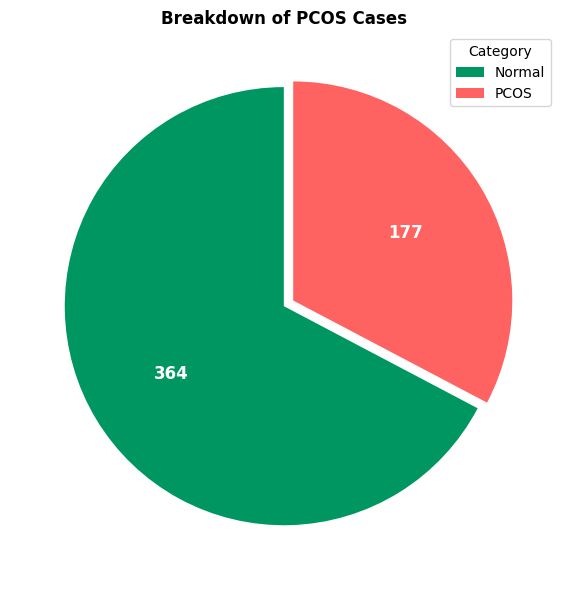

In [17]:
counts = df["PCOS (Y/N)"].value_counts()
total_data = counts.sum()

plt.figure(figsize=(10, 6))

handles, _, autotexts = plt.pie(
    x=counts,
    explode=[0, 0.05],
    colors=COLOR_PALETTE,
    autopct=lambda pct: f"{int(round(pct * total_data / 100))}",
    startangle=90
)

for autotext in autotexts:
    autotext.set_color("white")
    autotext.set_fontsize(12)
    autotext.set_fontweight("bold")

plt.legend(
    handles=handles,
    labels=["Normal", "PCOS"],
    title="Category",
    loc="upper right",
)

plt.title("Breakdown of PCOS Cases", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

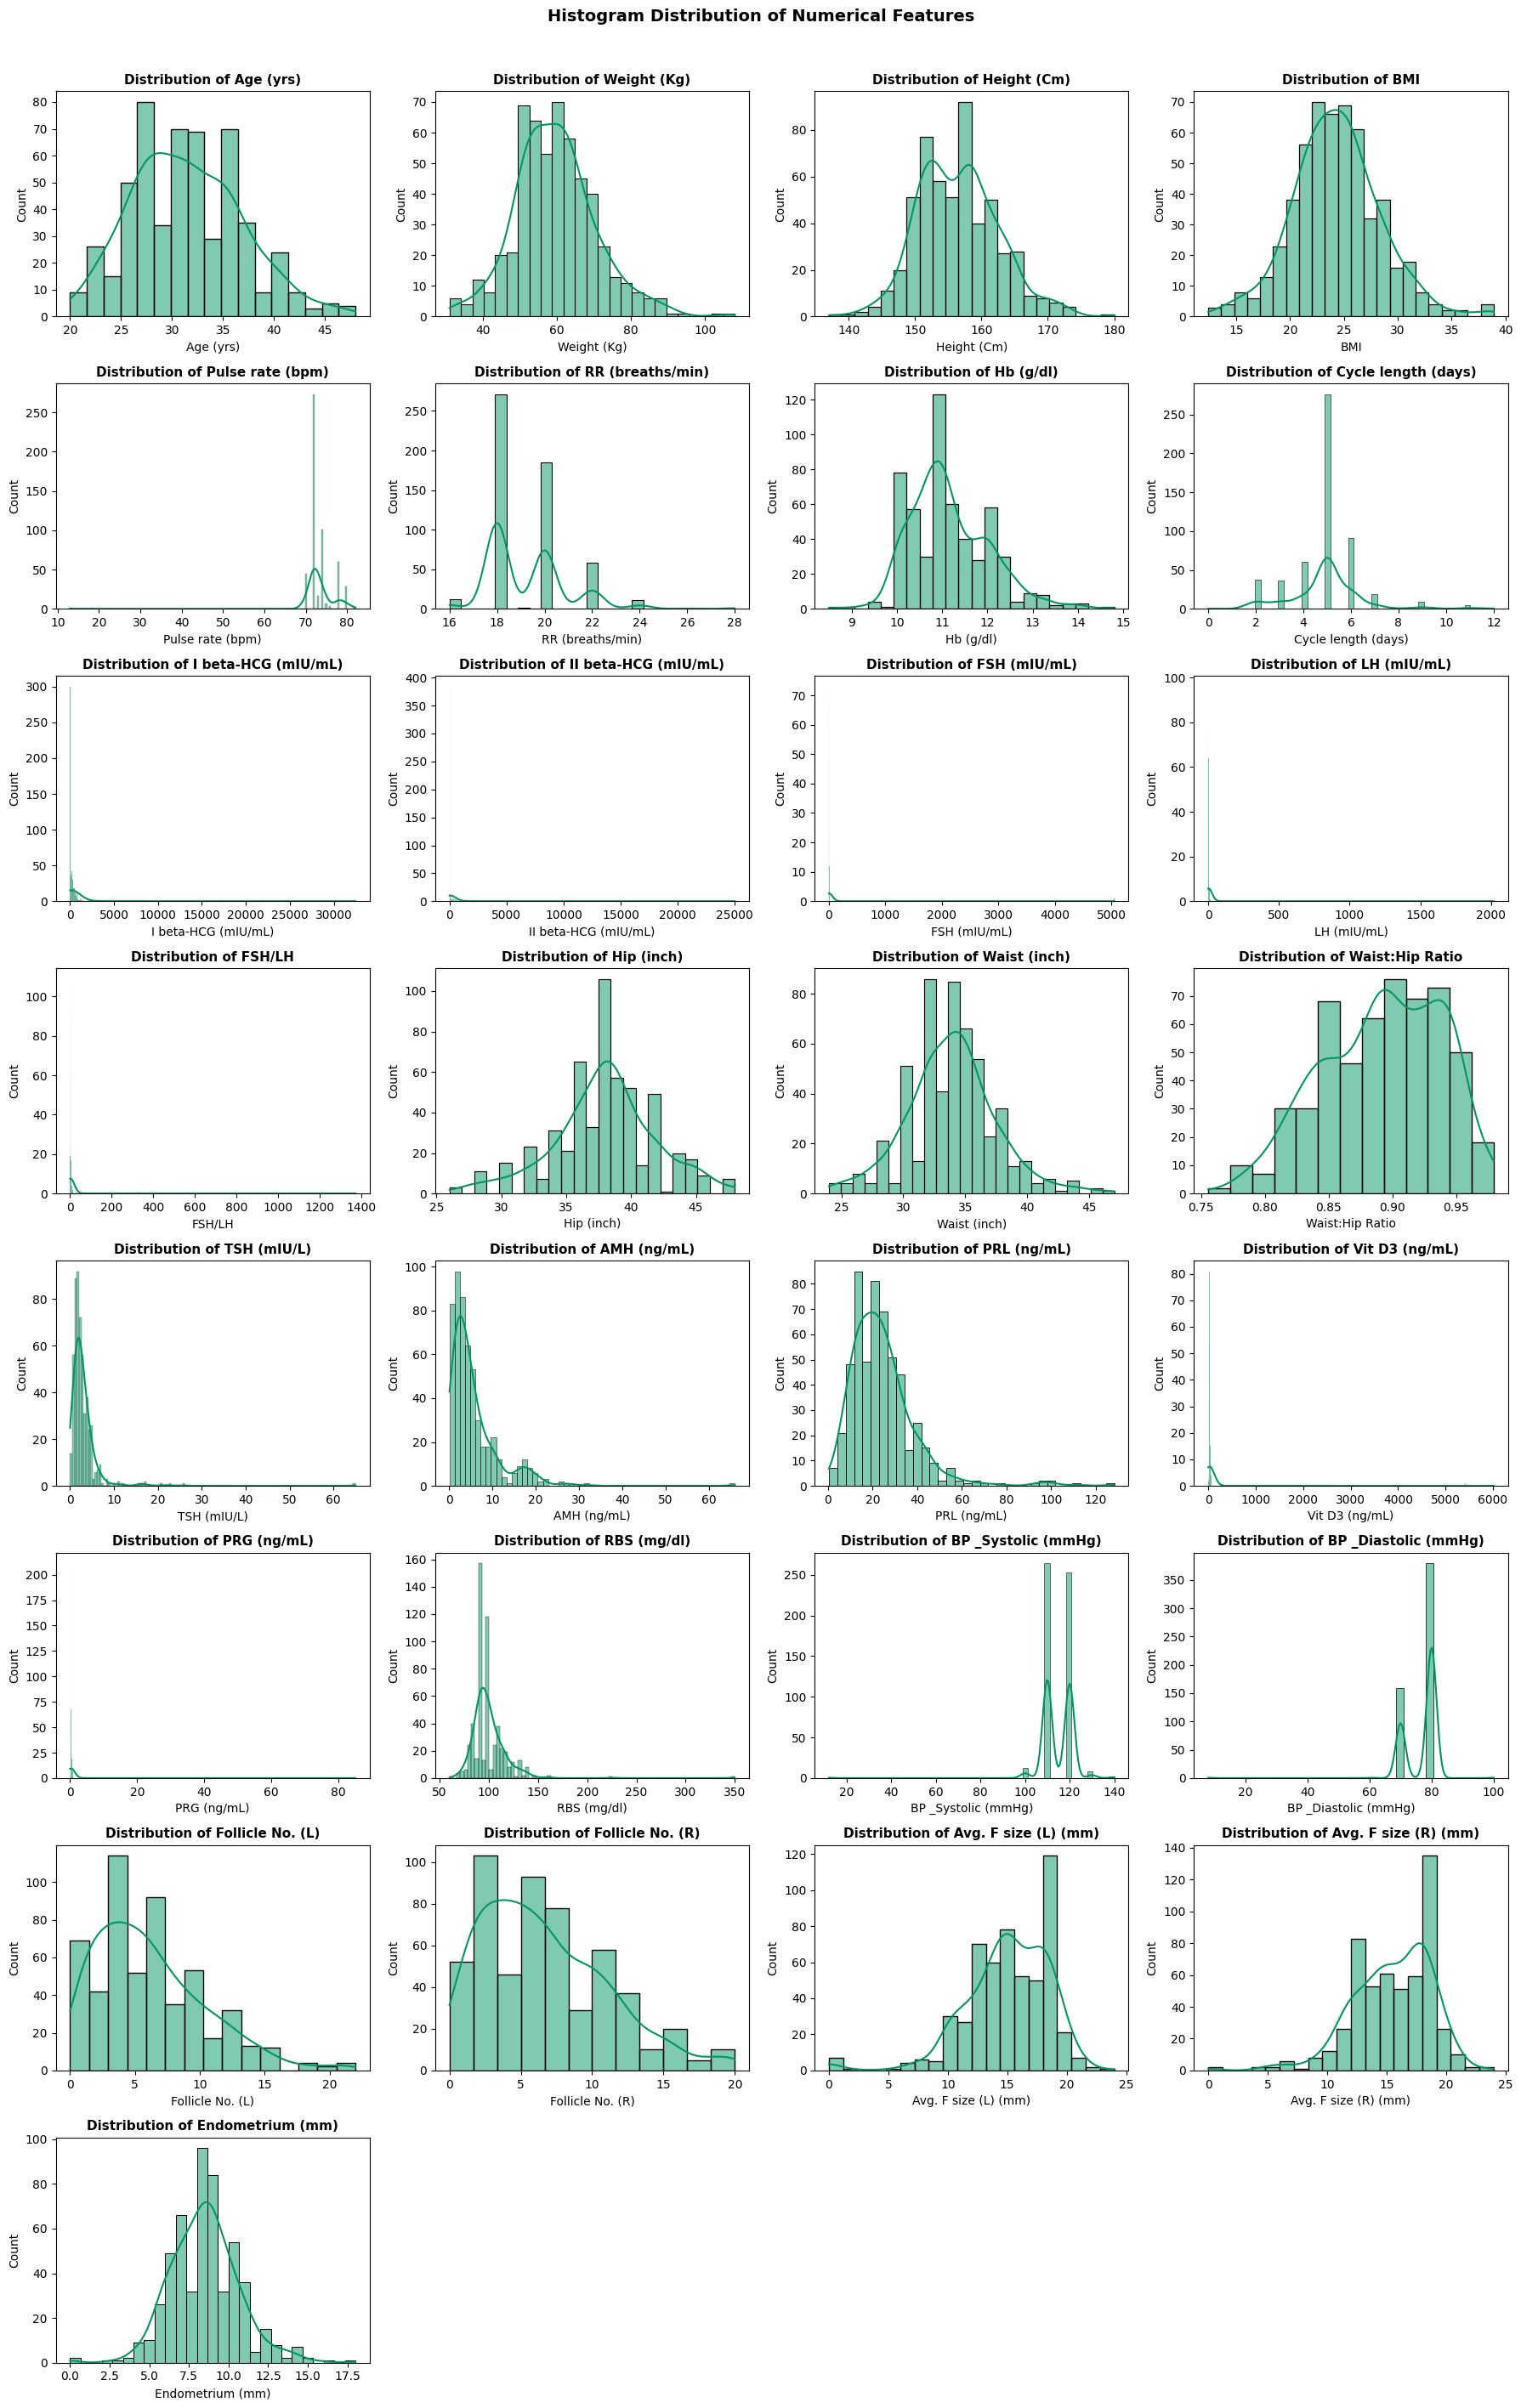

In [18]:
excluded_features = [
    "Sl. No", "Patient File No.","Blood Group", "No. of aborptions",
    "Marriage Status (Yrs)", "PCOS (Y/N)","Cycle (R/I)", "Pregnant (Y/N)",
    "Weight gain (Y/N)", "hair growth (Y/N)","Skin darkening (Y/N)",
    "Hair loss (Y/N)", "Pimples (Y/N)", "Fast food (Y/N)", "Reg.Exercise (Y/N)"
]

numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns
included_cols = [col for col in numeric_cols if col not in excluded_features]

ncols = 4
nrows = math.ceil(len(included_cols) / ncols)

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(18, nrows * 3.5))
axes = axes.flatten()

for i, col in enumerate(included_cols):
    sns.histplot(data=df, x=col, kde=True, color=COLOR_PALETTE[0], ax=axes[i])
    axes[i].set_title(f"Distribution of {col}", fontsize=11, fontweight="bold")
    axes[i].set_ylabel("Count")

for j in range(len(included_cols), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Histogram Distribution of Numerical Features", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

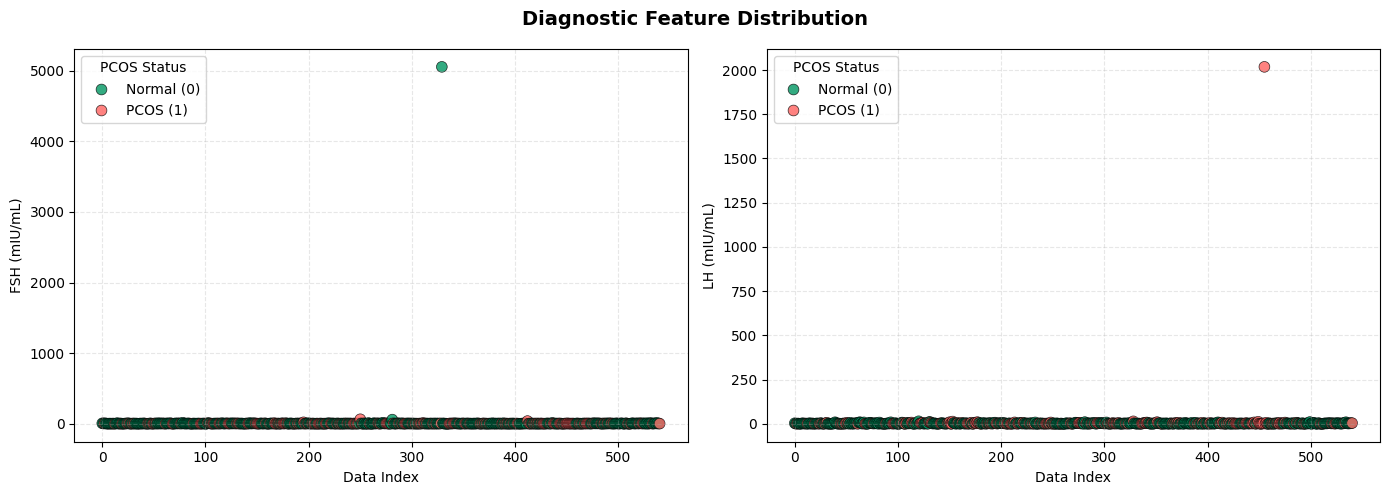

In [19]:
features = ["FSH (mIU/mL)", "LH (mIU/mL)"]

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 5))

for i, col in enumerate(features):
    sns.scatterplot(
        data=df,
        x=df.index,
        y=col,
        hue="PCOS (Y/N)",
        palette=COLOR_PALETTE,
        alpha=0.8,
        edgecolor="black",
        linewidth=0.5,
        s=60,
        ax=axes[i]
    )

    handles, _ = axes[i].get_legend_handles_labels()

    axes[i].set_xlabel("Data Index", fontsize=10)
    axes[i].set_ylabel(col, fontsize=10)
    axes[i].legend(handles=handles, title="PCOS Status", loc="upper left", labels=["Normal (0)", "PCOS (1)"])
    axes[i].grid(True, linestyle="--", alpha=0.3)

plt.suptitle("Diagnostic Feature Distribution", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

As shown, the ```FSH``` and ```LH``` features in this dataset were found to contain **anomalies** (not merely ordinary outliers), since extreme values in the thousands are clinically irrational and were identified as the result of data entry errors, thus requiring further handling.

## 4.3 Bivariate Analysis

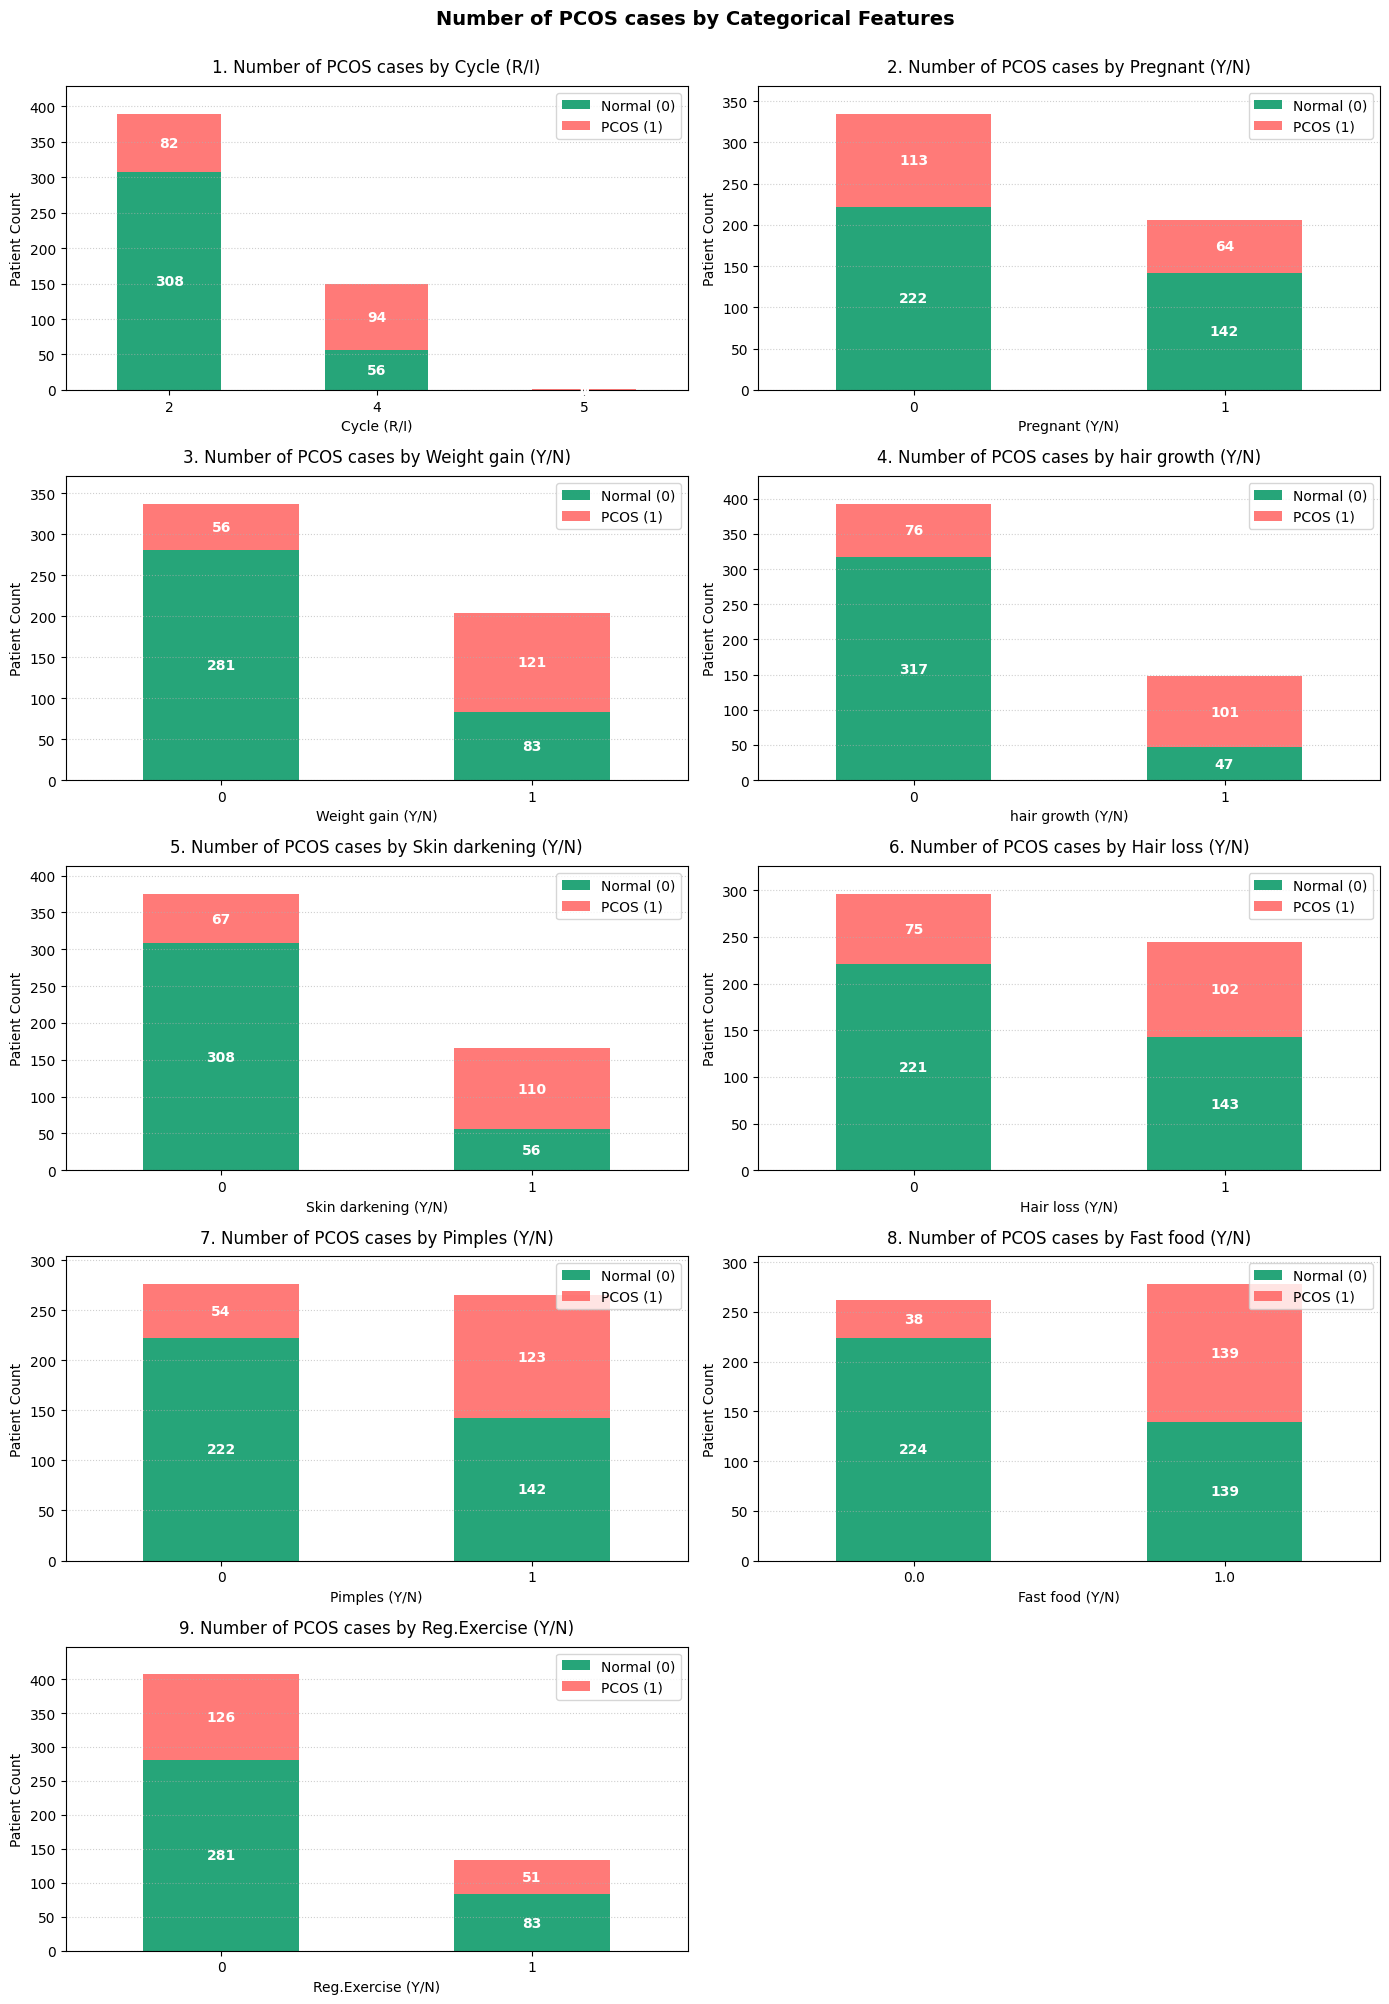

In [20]:
categorical_features = [col for col in df.columns if ("(Y/N)" in col and col != "PCOS (Y/N)") or col == "Cycle (R/I)"]

fig, axes = plt.subplots(5, 2, figsize=(14, 20))
axes = axes.flatten()

for i, col in enumerate(categorical_features):
    # Generate a contingency table (crosstab) against the target variable
    crosstab_data = pd.crosstab(df[col], df["PCOS (Y/N)"])

    crosstab_data.plot(
        kind="bar",
        stacked=True,
        color=COLOR_PALETTE,
        ax=axes[i],
        alpha=0.85
    )

    for container in axes[i].containers:
        axes[i].bar_label(
            container,
            label_type="center",
            fontsize=10,
            fontweight="bold",
            color="white"
        )

    axes[i].set_title(f"{i + 1}. Number of PCOS cases by {col}", fontsize=12, pad=10)
    axes[i].set_xlabel(col, fontsize=10)
    axes[i].set_ylabel("Patient Count", fontsize=10)
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=0)
    axes[i].grid(axis="y", linestyle=":", alpha=0.6)
    axes[i].legend(["Normal (0)", "PCOS (1)"], loc="upper right")

    # Dynamically adjust Y-axis limits to prevent visual crowding
    axes[i].set_ylim(0, df[col].value_counts().max() * 1.1)

axes[9].axis("off")

plt.suptitle("Number of PCOS cases by Categorical Features", fontsize=14, fontweight="bold", y=1)
plt.tight_layout()
plt.show()

1. Females with regular menstrual cycles (Code 2) have a very low proportion of PCOS, with the vast majority being normal. Conversely, for females with irregular cycles (Code 4), the proportion shifts dramatically, making them significantly more likely to be diagnosed with PCOS.
2. Females who do not experience weight gain are predominantly normal, with only a small fraction having PCOS. However, for those who do experience weight gain, the proportion of PCOS cases increases significantly, outnumbering the normal individuals in that group.
3. Females without excessive hair growth show a very low rate of PCOS diagnosis. In contrast, for females who exhibit hair growth, the likelihood of having PCOS rises sharply, making it a prominent characteristic group for PCOS patients.
4. The presence of skin darkening serves as a strong indicator for PCOS, as the majority of females in this category are diagnosed with the condition. Meanwhile, those without skin darkening remain overwhelmingly within the normal group."
5. Females experiencing hair loss show a noticeable increase in the proportion of PCOS cases compared to those who do not. However, compared to features like skin darkening or hair growth, the distinction between the normal and PCOS groups here is more balanced.
6. Females who suffer from pimples have a significantly higher proportion of PCOS cases compared to the pimple-free group. Having pimples noticeably increases the statistical likelihood of a PCOS diagnosis in this dataset.
7. Females who frequently consume fast food show a massive surge in PCOS cases, splitting the group exactly 50:50 with normal individuals. On the other hand, those who avoid fast food are heavily dominated by normal individuals, showing a strong link between fast food consumption and PCOS presence."

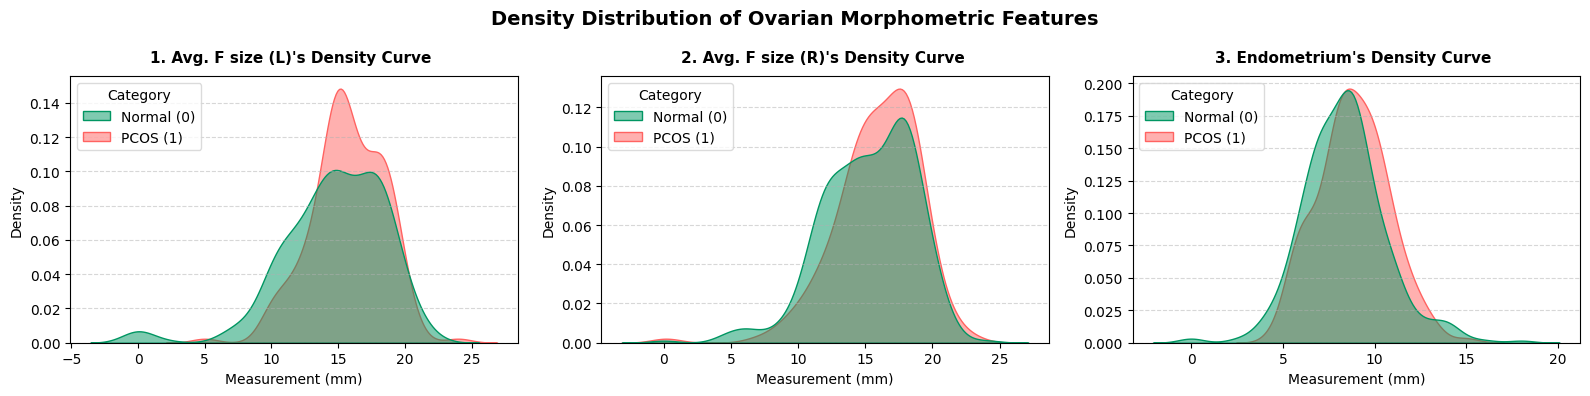

In [21]:
features = ["Avg. F size (L) (mm)", "Avg. F size (R) (mm)", "Endometrium (mm)"]

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(16, 4))
axes = axes.flatten()

for i, col in enumerate(features):
    ax = axes[i]

    sns.kdeplot(data=df, x=col, hue="PCOS (Y/N)", fill=True, common_norm=False, palette=COLOR_PALETTE, alpha=0.5, ax=ax)
    ax.set_title(f"{i + 1}. {col.split("(mm)")[0].rstrip()}'s Density Curve ", fontsize=11, fontweight="bold", pad=10)

    ax.set_xlabel("Measurement (mm)", fontsize=10)
    ax.set_ylabel("Density", fontsize=10)
    ax.grid(axis="y", linestyle="--", alpha=0.5)

    legend = ax.get_legend()
    if legend:
        handles = legend.legend_handles
        ax.legend(
            handles=handles,
            labels=["Normal (0)", "PCOS (1)"],
            title="Category",
            loc="upper left",
            frameon=True,
            facecolor="white",
            edgecolor="lightgray"
        )

plt.suptitle("Density Distribution of Ovarian Morphometric Features", fontsize=14, fontweight="bold", y=0.98)
plt.tight_layout()
plt.show()

1. The distribution of the average follicle size in the left ovary reveals a distinct concentration pattern between the two groups. Patients with PCOS exhibit a very sharp, highly concentrated density peak around the ```15 mm```
mark, whereas the Normal individuals displays a more flattened, wider distribution spanning evenly across ```14-18 mm```.

2. Mirroring the left ovary, the right ovarium's density curve shows that the PCOS group heavily dominates the larger size spectrum around ```15-18 mm```.
Conversely, the Normal group's distribution begins to rise earlier in smaller size range which is around ```10-13 mm```, indicating a more diverse variation in follicle development among Normal individuals.

3. In contrast to the ovarian follicle features, the thickness of the uterine Endometrium shows a highly overlapping distribution between the Normal and PCOS groups. Both cohorts share an identical peak density around ```8-9 mm```, indicating that endometrium thickness on its own lacks strong separability and may not serve as a primary distinguishing feature.

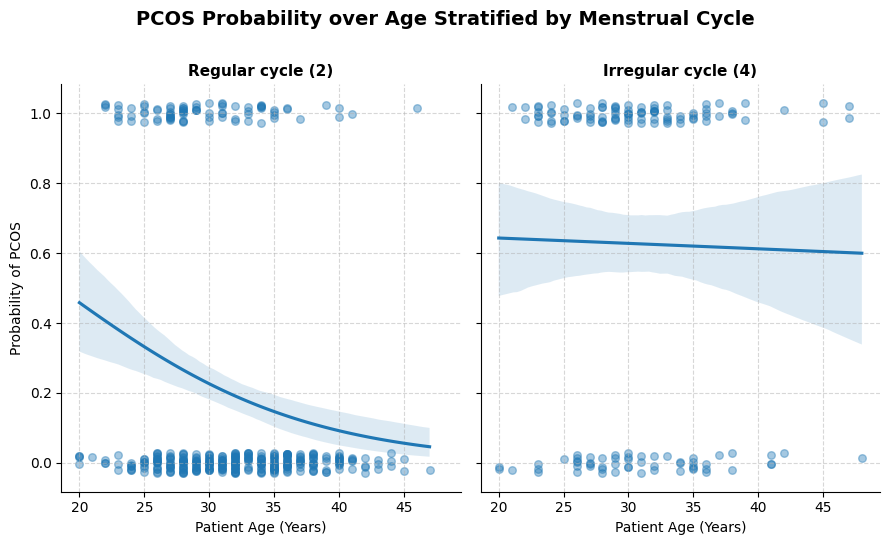

In [22]:
g = sns.lmplot(
    data=df,
    x="Age (yrs)",
    y="PCOS (Y/N)",
    col="Cycle (R/I)",
    col_order=[2, 4],
    logistic=True,
    y_jitter=0.03,
    height=5,
    aspect=0.9,
    scatter_kws={"alpha": 0.4, "s": 30}
)

g.set_axis_labels("Patient Age (Years)", "Probability of PCOS")

titles = ["Regular cycle (2)", "Irregular cycle (4)"]

for i, ax in enumerate(g.axes.flat):
    ax.set_title(titles[i], size=11, weight='bold')
    ax.grid(True, linestyle="--", alpha=0.5)

plt.suptitle("PCOS Probability over Age Stratified by Menstrual Cycle", fontsize=14, fontweight="bold", y=1.08)

plt.show()

For females who are getting older and have regular menstrual cycles (Code 2), the probability/risk of being diagnosed with PCOS has been shown to be significantly lower. However, for women with irregular menstrual cycles (Code 4), age has almost no effect on the risk of PCOS. Their risk of being diagnosed with PCOS remains consistently high (around 60%–65%) whether they are young or older.

## 4.4 Multivariate Analysis

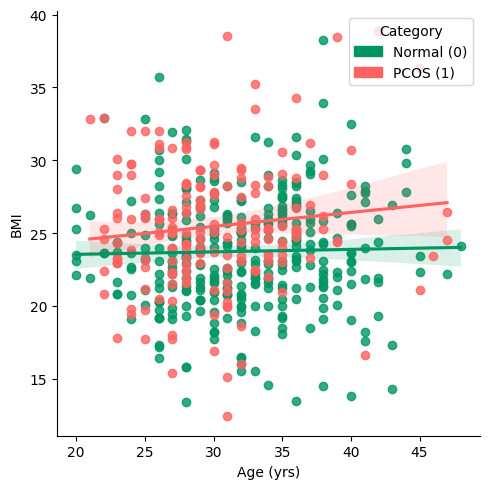

In [23]:
g = sns.lmplot(
    data=df,
    x="Age (yrs)",
    y="BMI",
    hue="PCOS (Y/N)",
    palette=COLOR_PALETTE,
    legend=False
)

handles = [
    mpatches.Patch(color=COLOR_PALETTE[0], label="Normal (0)"),
    mpatches.Patch(color=COLOR_PALETTE[1], label="PCOS (1)")
]

plt.legend(
    handles=handles,
    title="Category",
    loc="upper right",
    frameon=True
)

plt.show()

Females who experience weight gain or have a high BMI are far more likely to be diagnosed with PCOS than those with a stable BMI. However, this pattern is most evident and pronounced in older age groups, where the gap in body weight between individuals with normal weight and PCOS patients becomes particularly wide.

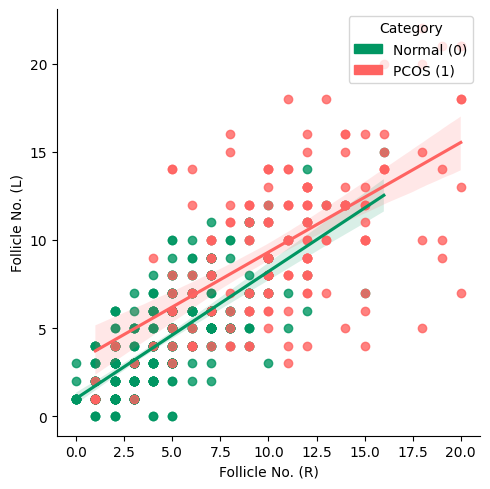

In [24]:
g = sns.lmplot(
    data=df,
    x="Follicle No. (R)",
    y="Follicle No. (L)",
    hue="PCOS (Y/N)",
    palette=COLOR_PALETTE,
    legend=False
)

handles = [
    mpatches.Patch(color=COLOR_PALETTE[0], label="Normal (0)"),
    mpatches.Patch(color=COLOR_PALETTE[1], label="PCOS (1)")
]

plt.legend(
    handles=handles,
    title="Category",
    loc="upper right",
    frameon=True
)

plt.show()

There is a strong, symmetrical positive correlation between both sides, meaning that as the number of follicles in the right ovary increases, the number in the left ovary also tends to rise for both groups. Let's take a closer look to understand the hidden information behind the pattern

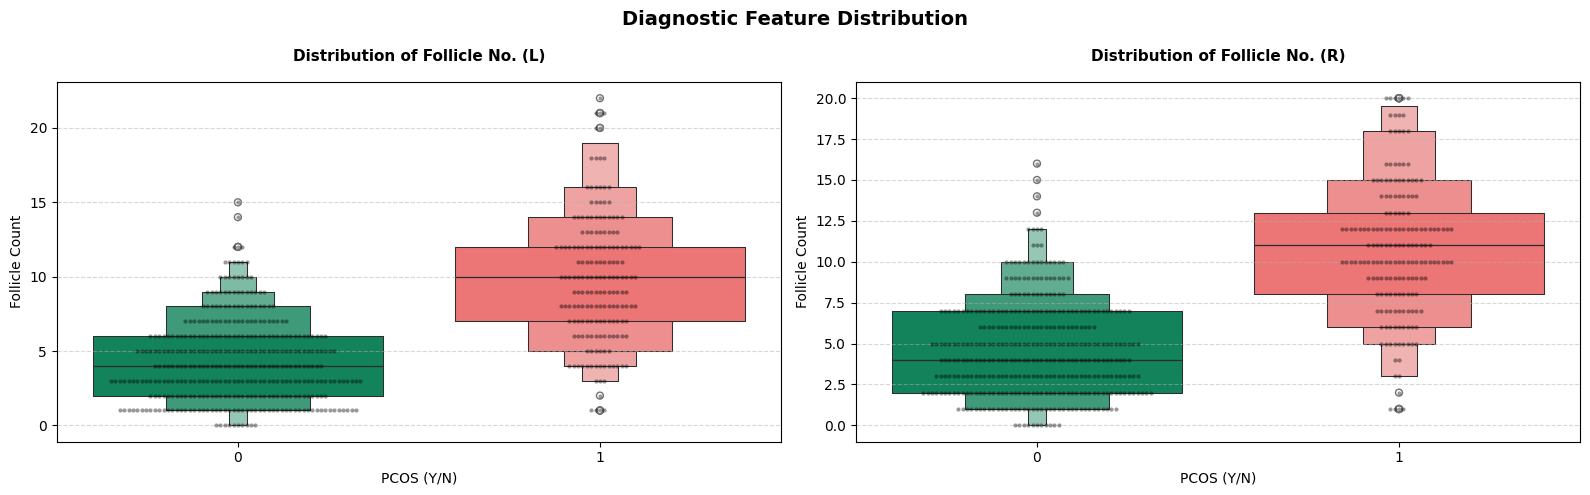

In [25]:
features = ["Follicle No. (L)", "Follicle No. (R)"]

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 5))

for i, col in enumerate(features):
    sns.boxenplot(x="PCOS (Y/N)", y=col, data=df, hue="PCOS (Y/N)", ax=axes[i], palette=COLOR_PALETTE, legend=False)
    sns.swarmplot(x="PCOS (Y/N)", y=col, data=df, ax=axes[i], color="black", alpha=0.4, size=3)

    axes[i].set_title(f"Distribution of {col}", fontsize=11, fontweight="bold", pad=15)
    axes[i].set_xlabel("PCOS (Y/N)", fontsize=10)
    axes[i].set_ylabel("Follicle Count", fontsize=10)
    axes[i].grid(axis="y", linestyle="--", alpha=0.5)

plt.suptitle("Diagnostic Feature Distribution", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

Furthermore, females diagnosed with PCOS consistently show a significantly higher number of follicles and unequal as well in both their right and left ovaries compared to normal individuals.

# **5. Data Preprocessing**

## 5.1 Handling Missing Values

In [26]:
features_has_null = df.columns[df.isnull().any()].tolist()

for feature in features_has_null:
  target_index = df[df[feature].isnull()].index[0]

  if feature == "Fast food (Y/N)":
    df.loc[target_index, feature] = df.loc[df["PCOS (Y/N)"] == 0, feature].mode().iloc[0]
    df[feature] = df[feature].astype(dtype="int64") # Convert for consistency
  else:
    df.loc[target_index, feature] = df.loc[df.index != target_index, feature].median()

In [27]:
# Quick verification
is_null_exists = df.isnull().any().any()

if not is_null_exists:
  print("✅ No missing values found")
else:
  print("❌ Missing values still exist")

✅ No missing values found


## 5.2 Handling Extreme Values

From the EDA stage, extremely high values were identified in the ```LH (mIU/mL)``` and ```FSH (mIU/mL)``` features. Therefore, we will address these before proceeding with further processing. These values will be substituted with the median of the data distribution based on pregnancy status, as they are closely related to pregnancy.

In [28]:
features = ["LH (mIU/mL)", "FSH (mIU/mL)"]

for feature in features:
  max_val_index = df[feature].argmax()

  pregnancy_status = 0 if feature == "LH (mIU/mL)" else 1

  df.loc[max_val_index, feature] = df[df["Pregnant (Y/N)"] == pregnancy_status][col].median()

## 5.3 Feature Engineering & Selection

First, we develop several new features that are highly relevant to the diagnosis of PCOS:
1.  **`LH/FSH`**
    The use of the term **FSH/LH** in the context of PCOS is considered a misconception because it reverses the logic behind the understanding of the disease's pathophysiology. Creating the correct ratio ensures the model captures the actual hormonal surge.
2.  **`Total Follicles`**
    According to the Rotterdam Criteria, women with PCOS are characterized by an excessive accumulation of immature follicles in the ovaries. This feature aggregates the total volume of follicles from both sides.
3.  **`Follicles Difference`**
    PCOS does not always affect both ovaries equally. This feature successfully captures **Ovarian Asymmetry** (where follicle accumulation occurs severely on one side only).

<br/>

After successfully creating these new features, we perform feature selection to remove irrelevant or redundant fetures:
*   **`FSH/LH`**
    This feature is permanently dropped because its underlying information has been fully replaced by our newly created `LH/FSH` feature.
*   **`Blood Group`**
    This feature is permanently dropped due to its absence of pathophysiological relevance to PCOS.
*   **`Marriage Status (Yrs)`**
    PCOS is driven by hormonal and genetic factors, completely independent of a patient's marital status.
*   **`No. of aborptions`**
    Pregnancy loss is a potential outcome of PCOS hormonal imbalance, not a cause or trigger of the disorder.


In [29]:
df["LH/FSH Ratio"] = df["LH (mIU/mL)"] / df["FSH (mIU/mL)"]
df["Total Follicles"] = df["Follicle No. (L)"] + df["Follicle No. (R)"]
df["Follicles Difference"] = abs(df["Follicle No. (L)"] - df["Follicle No. (R)"])

In [30]:
df.drop(columns=["FSH/LH", "Blood Group", "Marriage Status (Yrs)", "No. of aborptions"], axis=1, inplace=True)

## 5.4 Data Cleaning & Formatting
Drop columns that have no clinical relevance to PCOS and standardize its column names.
1. ```Sl.No``` : It is just numbering given to the data.
2. ```Patient File No``` : Unique number given to the data of each patients.

In [31]:
df.drop(columns=["Patient File No.", "Sl. No"], axis=1, inplace=True)

In [32]:
# Rename columns to follow snake case naming convention
def rename_cols(col):
    col = str(col).strip()
    col = re.sub(r"[^\w\s]", "", col)  # Delete special characters
    col = re.sub(r"\s+", "_", col)  # Replace spaces (single/double) with underscores
    col = re.sub(r'_+', '_', col) # Fix double or more underscore if detected after converting
    return col.lower()

df.columns = [rename_cols(col) for col in df.columns]

In [33]:
# Optional, uncomment below if you feel it's necessary

# new_cols = df.columns.tolist()
# df.insert(df.columns.get_loc("hip_inch"), "lhfsh_ratio", df.pop("lhfsh_ratio"))
# df.insert(df.columns.get_loc("avg_f_size_l_mm"), "total_follicles", df.pop("total_follicles"))
# df.insert(df.columns.get_loc("total_follicles") + 1, "follicles_difference", df.pop("follicles_difference"))

# target_col = new_cols.pop(0)
# new_cols.append(target_col)